In [1]:
import numpy as np 
import pickle 
import h5py
from scipy import stats
from tqdm.auto import tqdm
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import pearsonr
import pandas as pd
from pathlib import Path
import re
from tqdm.auto import tqdm



%matplotlib inline 
import matplotlib.pyplot as plt
import seaborn as sns
import src.util_analysis as util_analysis
from pprint import pprint

In [ ]:
analysis_dir = Path(f"/om/scratch/Thu/imgriff/binaural_unit_activation_analysis/")
all_models = list(analysis_dir.glob("*v10*/*.h5"))
models_to_run = []

for path in all_models:
    # if not path.is_dir():
    #     continue
    if 'rand' in path.stem:
        continue
    # if 'main' in path.stem and not ('latest' in path.stem or 'rand' in path.stem):
    #     continue 
    if 'control' in path.stem:
        continue
    if 'time_avg' in path.stem:
        continue
    if 'backbone' in path.stem:
        continue
    if 'early' in path.stem:
        continue
    if 'late_only' in path.stem:
        continue

    models_to_run.append(path)


model_name_dict = {path.stem: util_analysis.get_model_name(path.stem) for path in models_to_run}


In [3]:
models_to_run

[PosixPath('/om/scratch/Thu/imgriff/binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_4/word_task_v10_4MGB_ln_first_arch_4_model_activations_0dB_diotic.h5'),
 PosixPath('/om/scratch/Thu/imgriff/binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_7/word_task_v10_4MGB_ln_first_arch_7_model_activations_0dB_diotic.h5'),
 PosixPath('/om/scratch/Thu/imgriff/binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_1/word_task_v10_4MGB_ln_first_arch_1_model_activations_0dB_diotic.h5'),
 PosixPath('/om/scratch/Thu/imgriff/binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_12/word_task_v10_4MGB_ln_first_arch_12_model_activations_0dB_diotic.h5'),
 PosixPath('/om/scratch/Thu/imgriff/binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_2/word_task_v10_4MGB_ln_first_arch_2_model_activations_0dB_diotic.h5'),
 PosixPath('/om/scratch/Thu/imgriff/binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_6/word_task_v10_4MGB

## Re run the following if you have new architectures or have not generated the dict with min/max activation per layer

In [14]:
import os
import numpy as np
import h5py
from tqdm import tqdm
from multiprocessing import Pool, cpu_count

ACT_KEY_BASES = ['target'] # 'diff_sex_dist', 'same_sex_dist', 'nat_scene_dist']
NUM_WORKERS = min(8, cpu_count())  # You can bump this up if you want

def get_min_max_act(h5, layer_name):
    stats = [h5[f'{layer_name}_cued_{key}'] for key in ACT_KEY_BASES]
    return max(np.max(act) for act in stats), min(np.min(act) for act in stats)

def process_model(model_path):
    from pathlib import Path  # Ensures it's available in subprocesses
    import src.util_analysis       # Re-import in subprocess to avoid context issues

    model_path = Path(model_path)  # In case paths are serialized as strings
    model_name = util_analysis.get_model_name(model_path.parent.stem)
    model_data = {}

    try:
        with h5py.File(model_path, 'r', swmr=True) as h5:
            attn_keys = np.unique([
                k.split('_')[0] for k in h5.keys() if 'attn' in k and 'coch' not in k
            ])
            for layer in attn_keys:
                try:
                    max_act, min_act = get_min_max_act(h5, layer)
                    model_data[layer] = {"max": max_act, "min": min_act}
                except Exception as e:
                    model_data[layer] = {"error": str(e)}
    except Exception as e:
        return model_name, {"error": str(e)}

    return model_name, model_data

# Run the multiprocessing pool
with Pool(processes=NUM_WORKERS) as pool:
    results = list(tqdm(pool.imap_unordered(process_model, models_to_run), total=len(models_to_run), desc="Processing models"))

# Collect into dictionary
model_recs = {model_name: recs for model_name, recs in results}


Processing models: 100%|██████████| 10/10 [04:12<00:00, 25.22s/it]


In [18]:
## Save the results as a pickle file
pickle_path = 'v10_model_activation_min_max_per_layer.pkl'
with open(pickle_path, 'wb') as f:
    pickle.dump(model_recs, f)
# model_recs

# For each model, plot all gain functions using min and max per layer

In [4]:
## Save the results as a pickle file
pickle_path = 'v10_model_activation_min_max_per_layer.pkl'
with open(pickle_path, 'rb') as f:
    model_recs = pickle.load(f)
# model_recs

### Get gain parameters for each model from checkpoint

In [5]:
import torch 
## Setup functions for plotting all gain parameters 
import re 
import os 
from src.util_analysis import get_model_name

def get_ckpt_from_model_dir(model_dir):
    checkpoint_dir = model_dir / 'checkpoints'
    ckpt_paths = sorted(checkpoint_dir.glob("*.ckpt"), key=os.path.getctime)
    if len(ckpt_paths) == 0:
        return None
    ckpt_path = ckpt_paths[-1]
    return ckpt_path

def get_attn_layer_names(state_dict):
    attn_keys = [key for key in state_dict.keys() if 'attn' in key]
    pattern = re.compile(r'attn(\d+)')
    attn_layers = []
    for key in attn_keys:
        match = pattern.search(key)
        if match:
            layer_name = f"attn{match.group(1)}"
            attn_layers.append(layer_name)
        if 'attnfc' in key:
            attn_layers.append('attnfc')
    return np.unique(attn_layers)


def get_key_from_state_dict(state_dict, layer, param):
    # get the key from the state dict
    key = f"model._orig_mod.model_dict.{layer}.{param}"
    param = state_dict[key].item()
    return param  

import os 
from src.util_analysis import get_model_name

all_v10_models = list(Path("attn_cue_models").glob("word_task_v10*"))
main_fba_models = [path for path in all_v10_models if ('main' in path.stem or 'arch' in path.stem) and not '50Hz' in path.stem]


ckpt_path = get_ckpt_from_model_dir(main_fba_models[0])
ckpt = torch.load(ckpt_path, map_location=torch.device('cpu'))

# get human readable model name and checkpoint for each model 
good_model_dict = {}
for model in main_fba_models:
    # get the checkpoint path
    ckpt_path = get_ckpt_from_model_dir(model)
    # if the checkpoint exists, store state dict as value and human-readable model name as key
    if ckpt_path is not None:
        model_name = get_model_name(model.stem)
        good_model_dict[model_name] = torch.load(ckpt_path, map_location=torch.device('cpu'))['state_dict']







In [6]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


In [8]:
def natural_sort_key(s):
    return [int(text) if text.isdigit() else text for text in re.split(r'(\d+)', s)]

model_plot_order  = sorted(good_model_dict.keys(), key=natural_sort_key)
model_plot_order  = [model_plot_order[-1]] + model_plot_order[:-1]
model_plot_order

['Feature-gain main',
 'Feature-gain alt v1',
 'Feature-gain alt v2',
 'Feature-gain alt v4',
 'Feature-gain alt v6',
 'Feature-gain alt v7',
 'Feature-gain alt v8',
 'Feature-gain alt v9',
 'Feature-gain alt v10',
 'Feature-gain alt v12']

'attnfc'

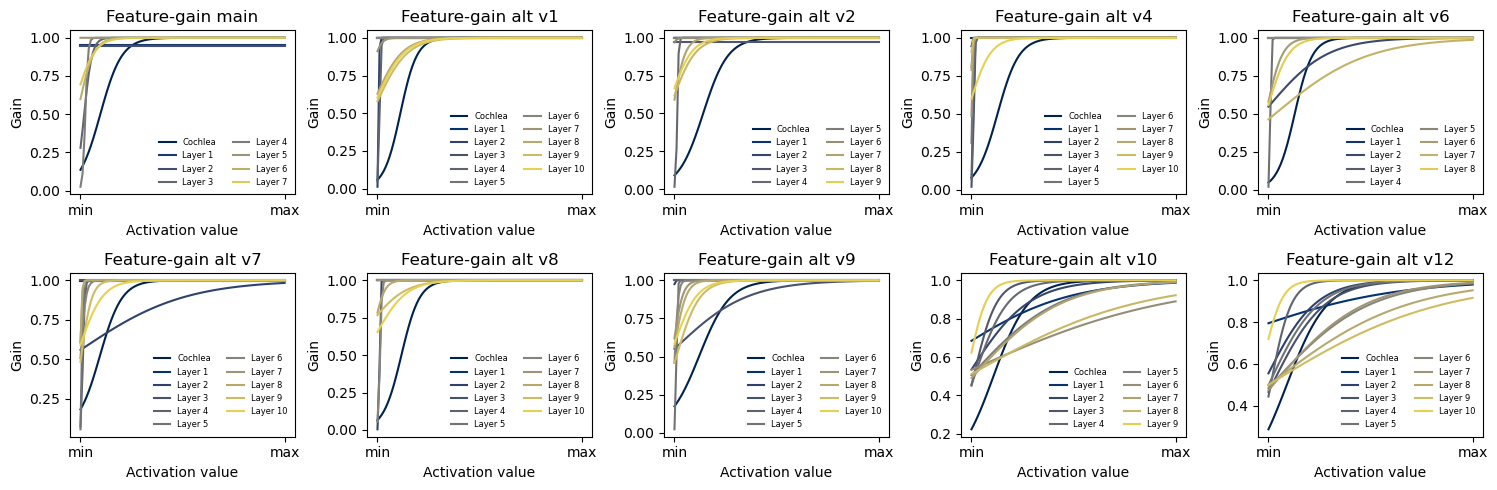

In [163]:
## Plot all attn modules on same panel 

cmap = plt.get_cmap("cividis")

n_models = len(good_model_dict)

n_columns = 5 
n_rows = 2


fig, axes = plt.subplots(n_rows, n_columns, figsize=(15, 5))
axes = axes.ravel()


x = np.linspace(0, 1, 100)
for i, model_name in enumerate(model_plot_order):
    state_dict = good_model_dict[model_name]
    attn_layers = get_attn_layer_names(state_dict)
    n_layers = len(attn_layers)
    layer_names = ['Cochlea' if ix == 0 else f"Layer {ix}" for ix in range(n_layers)]

    for j, (l_name, layer) in enumerate(zip(layer_names, attn_layers)):
        bias = get_key_from_state_dict(state_dict, layer, 'bias')
        slope = get_key_from_state_dict(state_dict, layer, 'slope')
        threshold = get_key_from_state_dict(state_dict, layer, 'threshold')

        # get min and max activation values for each layer 
        max_act = model_recs[model_name][layer]['max']
        min_act = model_recs[model_name][layer]['min']
        x_for_gains = np.linspace(min_act, max_act, 100)

        axes[i].plot(x, bias + (1-bias) * sigmoid((x_for_gains - threshold) * slope), color=cmap(j/n_layers), label=l_name)
        axes[i].set_title(model_name)
        axes[i].legend(fontsize=6, ncol=2, frameon=False)
        axes[i].set_xticks([0, 1])
        axes[i].set_xticklabels(['min', 'max'])
        axes[i].set_xlabel('Activation value')
        axes[i].set_ylabel('Gain')

        
plt.tight_layout()



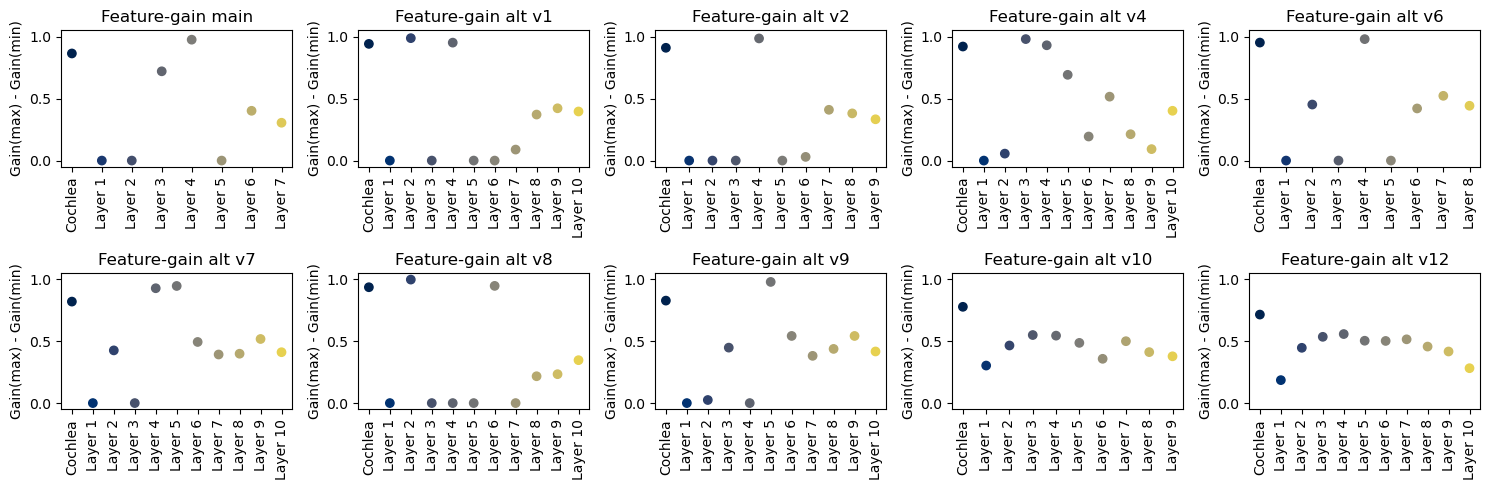

In [138]:
## For each model, plot delta between gain(max) and gain(min) as a function of layer

# get the delta between gain(max) and gain(min) for each layer
def get_delta_gain(state_dict, layer):
    bias = get_key_from_state_dict(state_dict, layer, 'bias')
    slope = get_key_from_state_dict(state_dict, layer, 'slope')
    threshold = get_key_from_state_dict(state_dict, layer, 'threshold')

    # get min and max activation values for each layer 
    max_act = model_recs[model_name][layer]['max']
    min_act = model_recs[model_name][layer]['min']

    gain_max = bias + (1-bias) * sigmoid((max_act - threshold) * slope)
    gain_min = bias + (1-bias) * sigmoid((min_act - threshold) * slope)
    
    return gain_max - gain_min


cmap = plt.get_cmap("cividis")

n_models = len(good_model_dict)

n_columns = 5 
n_rows = 2


fig, axes = plt.subplots(n_rows, n_columns, figsize=(15, 5))
axes = axes.ravel()


for i, model_name in enumerate(model_plot_order):
    state_dict = good_model_dict[model_name]
    attn_layers = get_attn_layer_names(state_dict)
    # print(attn_layers)
    n_layers = len(attn_layers)
    layer_names = ['Cochlea' if ix == 0 else f"Layer {ix}" for ix in range(n_layers)]

    deltas = [get_delta_gain(state_dict, layer) for layer in attn_layers]


    color_map = [cmap(j/n_layers) for j in range(n_layers)]
    x = np.arange(len(deltas))
    # for l in range(n_layers):
    axes[i].scatter(x, deltas, color=color_map)
    axes[i].set_title(model_name)
    # axes[i].legend(fontsize=8, ncol=2, frameon=False)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(layer_names, rotation=90)
    # axes[i].set_xlabel('Model stage')
    axes[i].set_ylabel('Gain(max) - Gain(min)')
    axes[i].set_ylim([-0.05, 1.05])

    
plt.tight_layout()




In [ ]:
## Sanity check both cases 

def get_curvature(x, fn):
    # get the first and second derivatives of the gain function
    dy_dx = np.gradient(fn, x)
    d2y_d2x = np.gradient(dy_dx, x)
    # calculate the curvature
    curvature = np.abs(d2y_d2x) / (1 + dy_dx**2)**1.5
    return curvature    

def total_curvature(curvature, x):
    # get the total curvature
    return np.trapz(curvature, x)


def curvature_range(curvature):
    # get the range of the curvature
    return np.max(curvature) - np.min(curvature)


def measure_jerk(x, curvature):
    # get the jerk of the curvature
    jerk = np.gradient(curvature, x)
    return jerk

def composite_curve(curvature, x):
    total_curvature = np.trapz(curvature, x)
    jerk = measure_jerk(x, curvature)
    delta_curvature = np.trapz(np.abs(jerk), x)
    return total_curvature + delta_curvature


def rms_jerk(curvature, x):
    # get the root mean square of the jerk
    jerk = measure_jerk(x, curvature)
    return np.sqrt(np.mean(jerk**2))


def curvature_entropy(curvature):
    # get the entropy of the curvature
    p = curvature / np.sum(curvature)
    return -np.sum(p * np.log(p + 1e-10))  # add small value to avoid log(0)


## Compute difference between inital sigmoid function and final sigmoid function
# this seems to be the easiest measure to interpret
def get_gain_fn(x, bias, slope, threshold):
    return bias + (1-bias) * sigmoid((x - threshold) * slope)

def distance_between_gain_fns(x, bias, slope, threshold):
    f_0 = get_gain_fn(x, 0, 1, 0)
    f_learned = get_gain_fn(x, bias, slope, threshold)
    return np.sqrt(np.mean((f_0 - f_learned)**2))



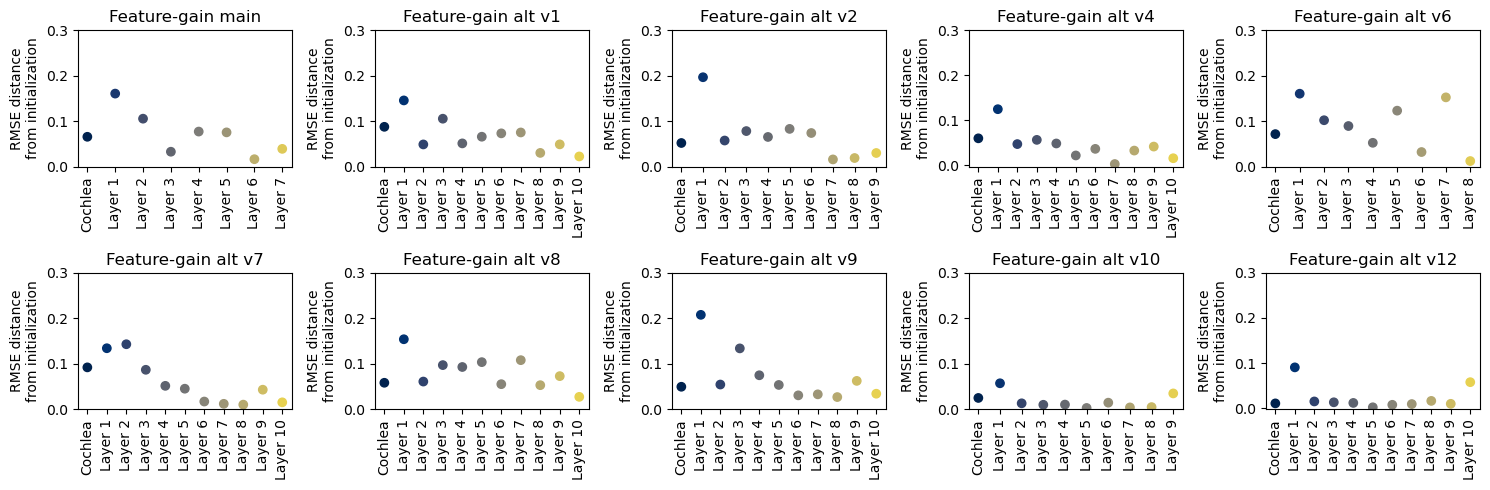

In [ ]:
## For each model, plot delta between gain(max) and gain(min) as a function of layer

# get the curvature of the gain function for each layer when evaluated at the min and max activation values
def curvature_of_gain_fn(state_dict, layer):
    bias = get_key_from_state_dict(state_dict, layer, 'bias')
    slope = get_key_from_state_dict(state_dict, layer, 'slope')
    threshold = get_key_from_state_dict(state_dict, layer, 'threshold')

    # get min and max activation values for each layer 
    max_act = model_recs[model_name][layer]['max']
    min_act = model_recs[model_name][layer]['min']

    x = np.linspace(min_act, max_act, 100)
    # gain = bias + (1-bias) * sigmoid((x - threshold) * slope)

    # curvature = get_curvature(x, gain) 
    # measure = curvature_range(curvature)

    measure = distance_between_gain_fns(x, bias, slope, threshold)
    # composite = curvature_entropy(curvature)   
    # curve_range = curvature_range(curvature)
    # curve_range=  np.std(curvature)
    # total_curvature = np.trapz(curvature, x)
    
    return measure #np.trapz(curvature, x)


cmap = plt.get_cmap("cividis")

n_models = len(good_model_dict)

n_columns = 5 
n_rows = 2


fig, axes = plt.subplots(n_rows, n_columns, figsize=(15, 5))
axes = axes.ravel()


for i, model_name in enumerate(model_plot_order):
    state_dict = good_model_dict[model_name]
    attn_layers = get_attn_layer_names(state_dict)
    # print(attn_layers)
    n_layers = len(attn_layers)
    layer_names = ['Cochlea' if ix == 0 else f"Layer {ix}" for ix in range(n_layers)]

    deltas = [curvature_of_gain_fn(state_dict, layer) for layer in attn_layers]


    color_map = [cmap(j/n_layers) for j in range(n_layers)]

    x = np.arange(len(deltas))
    # for l in range(n_layers):
    axes[i].scatter(x, deltas, color=color_map)
    axes[i].set_title(model_name)
    # axes[i].legend(fontsize=8, ncol=2, frameon=False)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(layer_names, rotation=90)
    # axes[i].set_xlabel('Model stage')
    axes[i].set_ylabel('RMSE distance\nfrom initialization')
    # axes[i].set_ylim([0, .3])
    axes[i].set_yticks(np.linspace(0, .3, 4))

plt.tight_layout()




0.24545113660162896
6.016361671627157


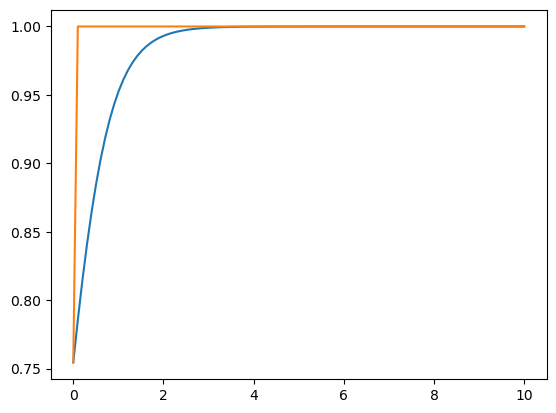

In [105]:
## Sanity check both cases 

def get_curvature(x, fn):
    # get the first and second derivatives of the gain function
    dy_dx = np.gradient(fn, x)
    d2y_d2x = np.gradient(dy_dx, x)
    # calculate the curvature
    curvature = np.abs(d2y_d2x) / (1 + dy_dx**2)**1.5
    return curvature    

def curvature_range(curvature):
    # get the range of the curvature
    return np.max(curvature) - np.min(curvature)

x = np.linspace(0, 10, 100)
gain = bias + (1-bias) * sigmoid((x - threshold) * 2)
plt.plot(x, gain)

# make step function

step = np.ones_like(x)
step[x < x[1]] = gain.min()
plt.plot(x, step)


# get curvature of gain function
curvature = get_curvature(x, gain)
d_curvature = np.abs(np.gradient(curvature, x))
curv_range = curvature_range(curvature)
print(curv_range)
# print(np.trapz(d_curvature, x))
# plt.plot(x, curvature)

# get curvature of step function
curvature_step = get_curvature(x, step)
d_curvature_step = np.abs(np.gradient(curvature_step, x))
curve_step_range = curvature_range(curvature_step)
print(curvature_range(curvature_step))
# print(np.trapz(d_curvature_step, x))

# print(np.trapz(np.abs(d_curvature), x) / np.trapz(np.abs(d_curvature_step), x))



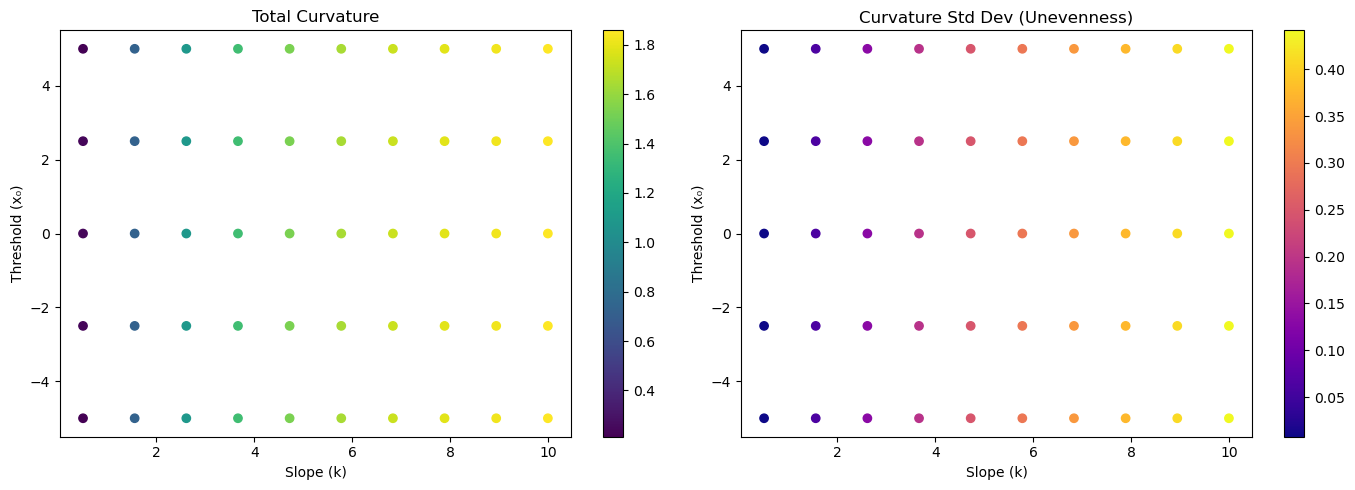

In [133]:
# Re-import necessary libraries after kernel reset
import numpy as np
import matplotlib.pyplot as plt

# Define sigmoid function
def sigmoid(x, k=1.0, x0=0.0, b=0.0):
    return 1 / (1 + np.exp(-k * (x - x0))) + b

# Generate x values
x = np.linspace(-10, 10, 1000)

# Define a grid of sigmoid parameters to test
slope_values = np.linspace(0.5, 10, 10)
threshold_values = np.linspace(-5, 5, 5)

# Store results
results = []

# Compute curvature metrics for each (slope, threshold) pair
for k in slope_values:
    for x0 in threshold_values:
        y = sigmoid(x, k=k, x0=x0)
        dy_dx = np.gradient(y, x)
        d2y_dx2 = np.gradient(dy_dx, x)
        curvature = np.abs(d2y_dx2) / (1 + dy_dx**2)**1.5

        curvature_std = np.std(curvature)
        total_curvature = np.trapz(curvature, x)

        results.append({
            "slope": k,
            "threshold": x0,
            "total_curvature": total_curvature,
            "curvature_std": curvature_std
        })

# Convert results to numpy arrays for plotting
slopes = np.array([r["slope"] for r in results])
thresholds = np.array([r["threshold"] for r in results])
total_curvs = np.array([r["total_curvature"] for r in results])
curv_stds = np.array([r["curvature_std"] for r in results])

# Create scatter plots
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

sc1 = axs[0].scatter(slopes, thresholds, c=total_curvs, cmap='viridis')
axs[0].set_title("Total Curvature")
axs[0].set_xlabel("Slope (k)")
axs[0].set_ylabel("Threshold (x₀)")
plt.colorbar(sc1, ax=axs[0])

sc2 = axs[1].scatter(slopes, thresholds, c=curv_stds, cmap='plasma')
axs[1].set_title("Curvature Std Dev (Unevenness)")
axs[1].set_xlabel("Slope (k)")
axs[1].set_ylabel("Threshold (x₀)")
plt.colorbar(sc2, ax=axs[1])

plt.tight_layout()
plt.show()
